# Classification Spam Emails

### 1. Problem Statement
Given a dataset of emails, determine whether each email is "spam" or "not spam."

### Data Colection
- Data source - https://www.kaggle.com/datasets/ashfakyeafi/spam-email-classification/data
- Data source include 1 file:
+ email.csv

### 2.Import library

In [247]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string                                                   # Processing strings related to the alphabet and special characters.
import re                                                       # Process the string using Regular Expressions to clean and extract data.

from sklearn.linear_model import LogisticRegression             # Classsification logistic model
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split            # Split data train/test
from sklearn.feature_extraction.text import TfidfVectorizer     # Change text to number (TF-IDF)
from sklearn.metrics import (
    accuracy_score,         
    classification_report,  # Report precision, recall, f1-score
    confusion_matrix,       # Confusion matrix
    ConfusionMatrixDisplay  # Visualization confusion matrix
)



# 3. Load Data

In [248]:
df = pd.read_csv('email.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [249]:
df.shape # show the number of rows and columns

(5572, 2)

In [250]:
df.info() # show the number of columns, column labels, data types, memory usage, and the number of non-null values in each column.

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [251]:
df.columns.tolist() # Transform dataframe to python list

['Category', 'Message']

In [252]:
df.isnull().sum() #It checks for missing values ​​in each column and returns the total number of empty values ​​in each column, helping to identify any spaces in your data.

Category    0
Message     0
dtype: int64

In [253]:
df.nunique() #It counts the number of unique different values ​​in each column, eliminating duplicate value loops.

Category       2
Message     5157
dtype: int64

In [254]:
df.drop_duplicates()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


# Distribution of Spam vs ham

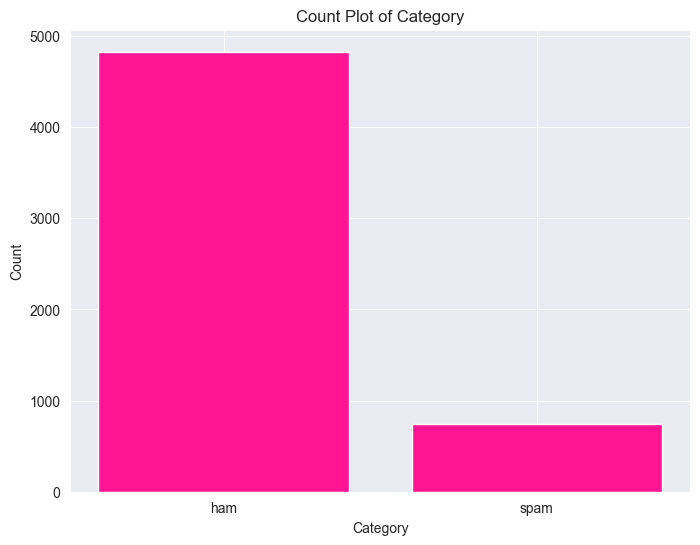

In [255]:
# Use a bar plot to find out the distribution of the data.
quality_counts = df['Category'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(quality_counts.index, quality_counts, color='deeppink')
plt.title('Count Plot of Category') # Distribution of data
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

# Plot Visualization

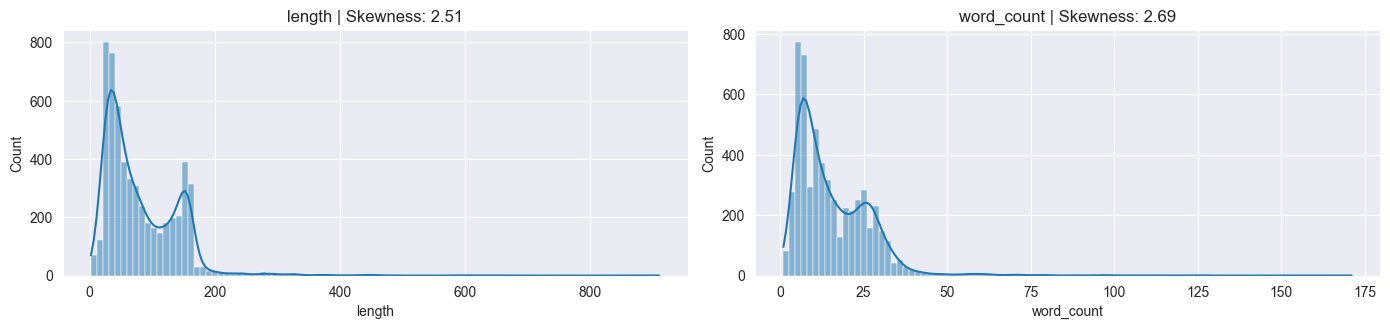

In [256]:
# Use a kernel density plot to understand the distribution and skewness in a column of data.
sns.set_style("darkgrid")

# Create a numeric feature from text.
df['length'] = df['Message'].apply(len) # length of message
df['word_count'] = df['Message'].apply(lambda x: len(x.split())) # number of words


numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_18188\3222787425.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Category', y='num_caps', data=df, palette={'ham': 'lightskyblue', 'spam': 'lightcoral'}, alpha=0.7)


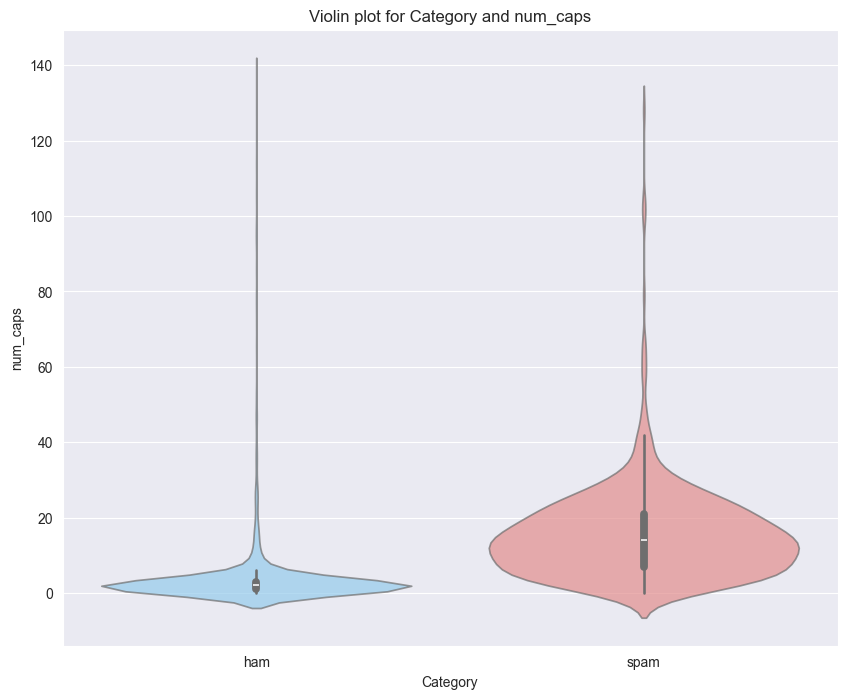

In [257]:
# Use a violin plot to check the relationship between category and Capital letters.
df['Category'] = df['Category'].astype(str)
df['num_caps'] = df['Message'].apply(lambda x: sum(1 for char in x if char.isupper()))

plt.figure(figsize=(10, 8))

sns.violinplot(x='Category', y='num_caps', data=df, palette={'ham': 'lightskyblue', 'spam': 'lightcoral'}, alpha=0.7)

plt.title('Violin plot for Category and num_caps')
plt.xlabel('Category')
plt.ylabel('num_caps')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_18188\2569991372.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


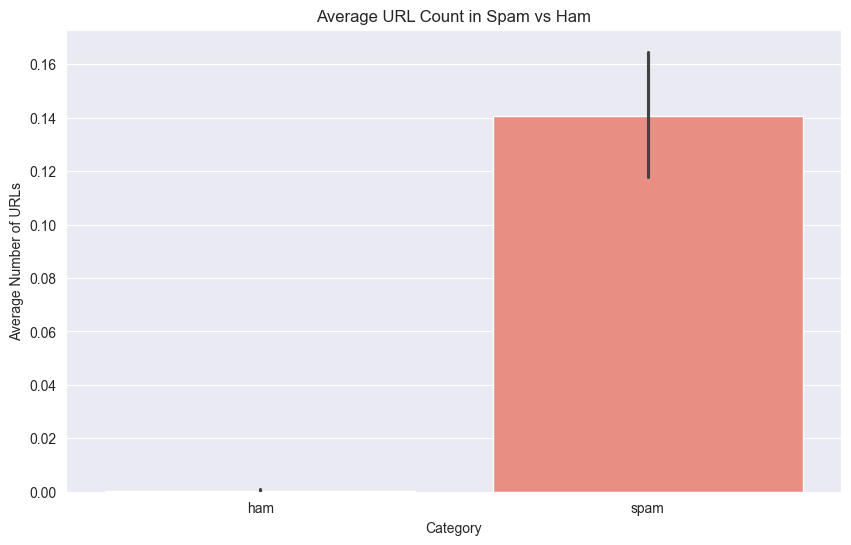

In [258]:
df['num_urls'] = df['Message'].apply(
    lambda x: len(re.findall(r'http\S+|www\S+', x))
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Category',
    y='num_urls',
    data=df,
    palette={'ham': 'skyblue', 'spam': 'salmon'}
)


plt.title('Average URL Count in Spam vs Ham')
plt.xlabel('Category')
plt.ylabel('Average Number of URLs')

plt.show()

# Preprocessing data
- Lower casing
- Remove punctuation
- Remove urls
- Remove Special Characters


In [259]:
# Convert 'Text' column to lowercase
df['Message'] = df['Message'].str.lower()
df.head()

,Category,Message,length,word_count,num_caps,num_urls
0,ham,"go until jurong point, crazy.. available only ...",111,20,3,0
1,ham,ok lar... joking wif u oni...,29,6,2,0
2,spam,free entry in 2 a wkly comp to win fa cup fina...,155,28,10,0
3,ham,u dun say so early hor... u c already then say...,49,11,2,0
4,ham,"nah i don't think he goes to usf, he lives aro...",61,13,2,0


In [260]:
def remove_punctuation(text):
    return re.sub(f"[{string.punctuation}]", "", text)

df['Message'] = df['Message'].apply(remove_punctuation)
df['num_punctuation'] = df['Message'].apply(
    lambda x: sum(1 for c in x if c in string.punctuation)
)
df.head()

,Category,Message,length,word_count,num_caps,num_urls,num_punctuation
0,ham,go until jurong point crazy available only in ...,111,20,3,0,0
1,ham,ok lar joking wif u oni,29,6,2,0,0
2,spam,free entry in 2 a wkly comp to win fa cup fina...,155,28,10,0,0
3,ham,u dun say so early hor u c already then say,49,11,2,0,0
4,ham,nah i dont think he goes to usf he lives aroun...,61,13,2,0,0


In [261]:
def remove_number(text):
    return re.sub(r"\d+", "", text)

df['Message'] = df['Message'].apply(remove_number)
df.head()

,Category,Message,length,word_count,num_caps,num_urls,num_punctuation
0,ham,go until jurong point crazy available only in ...,111,20,3,0,0
1,ham,ok lar joking wif u oni,29,6,2,0,0
2,spam,free entry in a wkly comp to win fa cup final...,155,28,10,0,0
3,ham,u dun say so early hor u c already then say,49,11,2,0,0
4,ham,nah i dont think he goes to usf he lives aroun...,61,13,2,0,0


In [262]:
def remove_urls(text):
    return re.sub(r'http\S+|www\S+', '', text)

df['Message'] = df['Message'].apply(remove_urls)
df.head(20)

,Category,Message,length,word_count,num_caps,num_urls,num_punctuation
0,ham,go until jurong point crazy available only in ...,111,20,3,0,0
1,ham,ok lar joking wif u oni,29,6,2,0,0
2,spam,free entry in a wkly comp to win fa cup final...,155,28,10,0,0
3,ham,u dun say so early hor u c already then say,49,11,2,0,0
4,ham,nah i dont think he goes to usf he lives aroun...,61,13,2,0,0
5,spam,freemsg hey there darling its been weeks now ...,147,32,7,0,0
6,ham,even my brother is not like to speak with me t...,77,16,2,0,0
7,ham,as per your request melle melle oru minnaminun...,160,26,10,0,0
8,spam,winner as a valued network customer you have b...,157,26,12,0,0
9,spam,had your mobile months or more u r entitled t...,154,29,14,0,0


In [263]:
def remove_special_characters(text):
    pattern = r'[^a-zA-Z0-9\s]'  # Matches any character that is not alphanumeric or whitespace
    
    # Replace special characters with an empty string
    clean_text = re.sub(pattern, '', text)
    
    return clean_text

# Apply the function to the 'Message' column
df['Message'] = df['Message'].apply(remove_special_characters)
df.head()

,Category,Message,length,word_count,num_caps,num_urls,num_punctuation
0,ham,go until jurong point crazy available only in ...,111,20,3,0,0
1,ham,ok lar joking wif u oni,29,6,2,0,0
2,spam,free entry in a wkly comp to win fa cup final...,155,28,10,0,0
3,ham,u dun say so early hor u c already then say,49,11,2,0,0
4,ham,nah i dont think he goes to usf he lives aroun...,61,13,2,0,0


- Label encryption

In [264]:
df = df[df["Category"].isin(['ham', 'spam'])] # only collect spam and ham samples.

X = df["Message"]
y = df["Category"]

print("Check label distribution: ")
print(y.value_counts())

print("\nCheck the label distribution by percentages: ")
print(y.value_counts()/len(y))

y = y.map({
    'ham': 0,
    'spam': 1
}) # Change label to number

Check label distribution: 
Category
ham     4825
spam     747
Name: count, dtype: int64

Check the label distribution by percentages: 
Category
ham     0.865937
spam    0.134063
Name: count, dtype: float64


# Model Building

- Split the training/test set

In [265]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

print("The training/testing time has been split at an 80/20 ratio.")

The training/testing time has been split at an 80/20 ratio.


- TF-IDF Vectorizer

In [266]:
# Convert text to digital vectors
vectorizer = TfidfVectorizer()

# Train vectorizer with training data.
vectorizer.fit(X_train)

# Convert training data into digital vectors.
X_train_tfidf = vectorizer.transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)


TRAINING MODEL

In [267]:
# Use logistic Regression
model = LogisticRegression(
    class_weight = "balanced"
)

model.fit(X_train_tfidf, y_train)

print("The model has been trained.")

The model has been trained.


EVALUATION MODEL

Logistic Regression (train 80% / test 20%)
Accuracy:  0.9748878923766816

Confusion Matrix: 


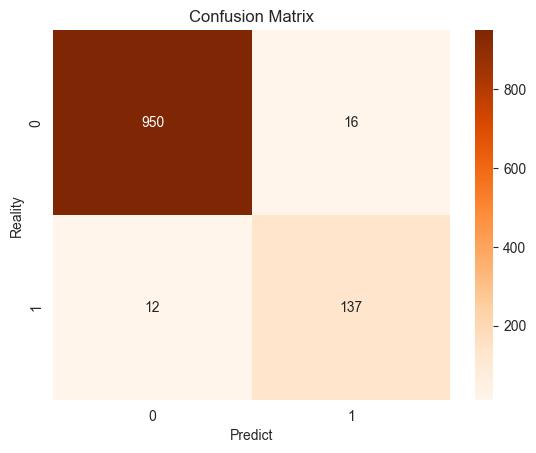


Classification Report: 
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       966
           1       0.90      0.92      0.91       149

    accuracy                           0.97      1115
   macro avg       0.94      0.95      0.95      1115
weighted avg       0.98      0.97      0.98      1115



In [268]:
# Predict labels on the test set.
y_pred = model.predict(X_test_tfidf)

# calculate accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression (train 80% / test 20%)")
print("Accuracy: ", acc)

# Draw confusion matrix
print("\nConfusion Matrix: ")
cm = confusion_matrix(y_test, y_pred)
plt.Figure(figsize=(4,4))
sns.heatmap(
    cm,             
    annot = True,   # Print the value in each cell.
    fmt = "d",      # integer format
    cmap = "Oranges"  # orange
)
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("Reality")
plt.show()

# Report of key metrics: precision, recall, F1-score
print("\nClassification Report: ")
print(classification_report(y_test, y_pred))